In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import os

dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path))


['YAF_neutral', 'YAF_sad', 'YAF_happy', 'YAF_fear', 'YAF_disgust', 'YAF_pleasant_surprised', 'OAF_Sad', 'YAF_angry', 'TESS Toronto emotional speech set data', 'OAF_Pleasant_surprise', 'OAF_neutral', 'OAF_happy', 'OAF_Fear', 'OAF_disgust', 'OAF_angry']


In [64]:
sample_file = "/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_germ_angry.wav"

In [65]:
import librosa

audio, sr = librosa.load(sample_file, sr=16000)

print(sr)
print(len(audio))

16000
23717


In [66]:
import librosa
import numpy as np

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 47)


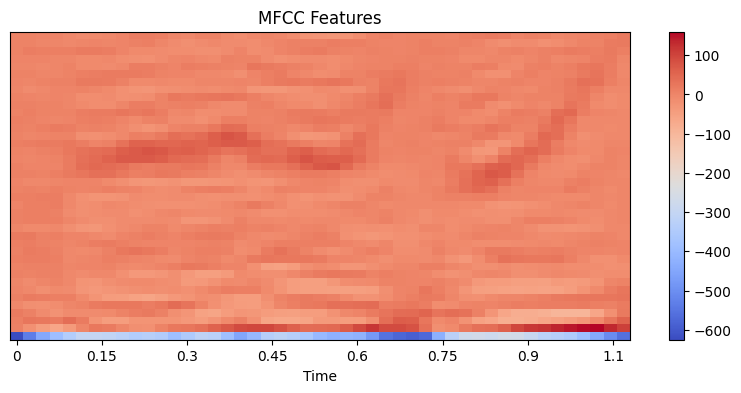

In [67]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

In [68]:
mfcc_mean = np.mean(mfcc.T, axis=0)

print(mfcc_mean.shape)

(40,)


In [69]:
emotion = sample_file.split("/")[-2]

print(emotion)

OAF_angry


In [70]:
import os
import librosa
import numpy as np

In [71]:
dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

In [72]:
X = []
y = []

In [73]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # CONVERT TO FIXED SIZE
                mfcc_mean = np.mean(
                    mfcc.T,
                    axis=0
                )

                # SAVE FEATURES
                X.append(mfcc_mean)

                # SAVE LABEL
                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional s

/tmp/ipykernel_16819/489790093.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: OAF_neutral
Processing: OAF_happy
Processing: OAF_Fear
Processing: OAF_disgust
Processing: OAF_angry


In [74]:
X = np.array(X)
y = np.array(y)

In [75]:
print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (2753, 40)
Label Shape: (2753,)


In [76]:
print(y[:10])

['YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral'
 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral']


In [77]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [78]:
print(y[:5])

print(y_encoded[:5])

['YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral']
[11 11 11 11 11]


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [80]:
print(X_train.shape)
print(X_test.shape)

(2202, 40)
(551, 40)


In [81]:
import torch
import torch.nn as nn
import torch.optim as optim

In [82]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [83]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)


torch.Size([2202, 40])
torch.Size([2202])


In [84]:
class EmotionClassifier(nn.Module):

    def __init__(self):

        super(EmotionClassifier, self).__init__()

        self.fc1 = nn.Linear(40, 128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)

        self.fc3 = nn.Linear(
            64,
            len(np.unique(y_encoded))
        )

    def forward(self, x):

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        x = self.relu(x)

        x = self.fc3(x)

        return x

In [85]:
model = EmotionClassifier()

print(model)

EmotionClassifier(
  (fc1): Linear(in_features=40, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=14, bias=True)
)


In [86]:
criterion = nn.CrossEntropyLoss()

In [87]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [88]:
epochs = 100

for epoch in range(epochs):

    # FORWARD PASS
    outputs = model(X_train_tensor)

    # CALCULATE LOSS
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # RESET GRADIENTS
    optimizer.zero_grad()

    # BACKPROPAGATION
    loss.backward()

    # UPDATE WEIGHTS
    optimizer.step()

    # PRINT LOSS
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 2.9272
Epoch [20/100], Loss: 2.1242
Epoch [30/100], Loss: 1.3826
Epoch [40/100], Loss: 0.9233
Epoch [50/100], Loss: 0.6258
Epoch [60/100], Loss: 0.4326
Epoch [70/100], Loss: 0.3122
Epoch [80/100], Loss: 0.2345
Epoch [90/100], Loss: 0.1819
Epoch [100/100], Loss: 0.1449


In [89]:
with torch.no_grad():

    outputs = model(X_test_tensor)

    _, predicted = torch.max(outputs, 1)

    accuracy = (
        predicted == y_test_tensor
    ).sum().item() / len(y_test_tensor)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 98.19%


In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

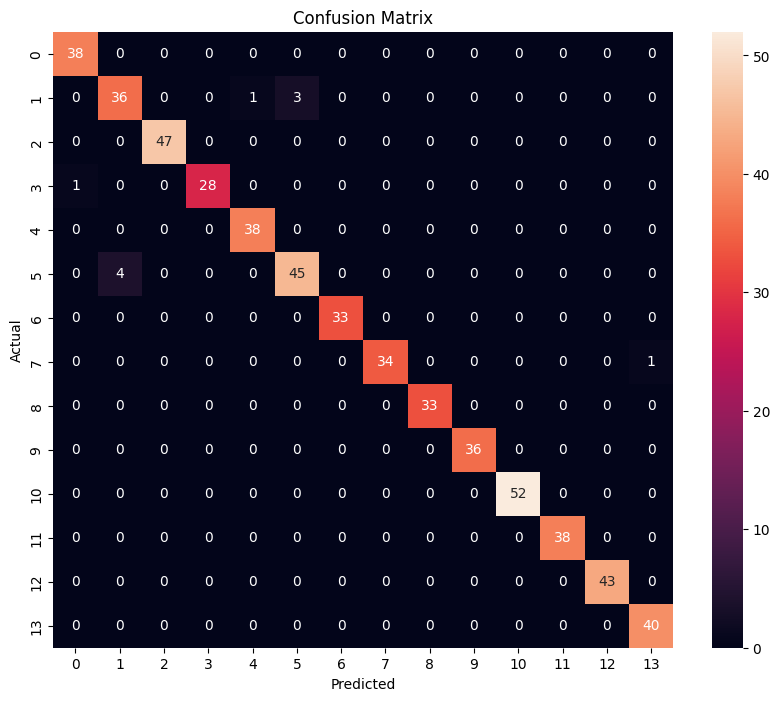

In [91]:
cm = confusion_matrix(
    y_test_tensor,
    predicted
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [92]:
np.mean(mfcc.T, axis=0)

array([-3.9076599e+02,  3.4121479e+01, -8.0323677e+00, -1.4107442e+01,
        3.1983030e+00, -1.2976272e+01, -2.4877041e+01, -1.4231112e+01,
       -1.2858116e+01,  5.7507172e+00, -2.1340559e+00,  8.1898737e+00,
       -8.1714666e-01,  2.0294526e+00, -4.8693416e-01, -1.3787301e+00,
        2.0993056e-02, -7.2305684e+00, -8.5981445e+00,  4.7083184e-02,
       -9.5645342e+00,  1.0426090e+01,  1.3279999e+01,  2.2196091e+01,
        2.7778141e+01,  2.4649675e+01,  1.5200030e+01,  8.7590647e+00,
        3.4968405e+00,  1.4158366e+01,  3.9710505e+00,  8.3423805e+00,
       -2.5544648e+00,  9.4873924e+00,  1.7358965e+00,  4.0983179e-01,
        1.0502607e+00,  3.9243665e-01,  4.4260263e+00,  5.8126869e+00],
      dtype=float32)

In [93]:
MAX_PAD_LEN = 200

X = []
y = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # PAD OR TRUNCATE
                if mfcc.shape[1] < MAX_PAD_LEN:

                    pad_width = MAX_PAD_LEN - mfcc.shape[1]

                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )

                else:

                    mfcc = mfcc[:, :MAX_PAD_LEN]

                X.append(mfcc)

                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

In [94]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2753, 40)
(2753,)


In [95]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [97]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [98]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [99]:
import torch.nn as nn

class CNNLSTM(nn.Module):

    def __init__(self, num_classes):

        super(CNNLSTM, self).__init__()

        # CNN PART
        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # LSTM PART
        self.lstm = nn.LSTM(
            input_size=32 * 20,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # CLASSIFIER
        self.fc = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # SHAPE:
        # batch, channel, height, width

        batch_size, channels, height, width = x.size()

        # RESHAPE FOR LSTM
        x = x.permute(0, 3, 1, 2)

        x = x.contiguous().view(
            batch_size,
            width,
            channels * height
        )

        # LSTM
        lstm_out, _ = self.lstm(x)

        # LAST TIME STEP
        x = lstm_out[:, -1, :]

        # CLASSIFIER
        x = self.fc(x)

        return x

In [100]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [101]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [102]:
print(type(X))
print(type(y))

print(len(X))
print(len(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
2753
2753


In [103]:
print(X[0].shape)
print(X[1].shape)
print(X[2].shape)

(40,)
(40,)
(40,)


In [104]:
X = np.array(X, dtype=np.float32)

print(X.shape)
print(X.dtype)

(2753, 40)
float32


In [105]:
y = np.array(y)

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [107]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)

torch.Size([2202, 40])


In [108]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [109]:
import torch
import torch.nn as nn

class CNNLSTM(nn.Module):

    def __init__(self, num_classes):

        super(CNNLSTM, self).__init__()

        # CNN BLOCK
        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # LSTM BLOCK
        self.lstm = nn.LSTM(
            input_size=32 * 20,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # CLASSIFIER
        self.fc = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # SHAPE
        batch_size, channels, height, width = x.size()
        print(x.shape)

        # RESHAPE FOR LSTM
        x = x.permute(0, 3, 1, 2)

        x = x.contiguous().view(
            batch_size,
            width,
            channels * height
        )

        # LSTM
        lstm_out, _ = self.lstm(x)

        # LAST OUTPUT
        x = lstm_out[:, -1, :]

        # FINAL CLASSIFIER
        x = self.fc(x)

        return x

In [110]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [111]:
criterion = nn.CrossEntropyLoss()

In [112]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [113]:
print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [114]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

In [115]:
print(X_train_tensor.shape)

torch.Size([2202, 1, 1, 40])


In [116]:
print("X_train_tensor shape:")
print(X_train_tensor.shape)

print("\nOne sample shape:")
print(X_train_tensor[0].shape)

print("\nModel test:")
test_input = X_train_tensor[:2]

print(test_input.shape)

X_train_tensor shape:
torch.Size([2202, 1, 1, 40])

One sample shape:
torch.Size([1, 1, 40])

Model test:
torch.Size([2, 1, 1, 40])


In [117]:
MAX_PAD_LEN = 200

X = []
y = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # IMPORTANT:
                # DO NOT USE np.mean()

                # PAD / TRUNCATE
                if mfcc.shape[1] < MAX_PAD_LEN:

                    pad_width = MAX_PAD_LEN - mfcc.shape[1]

                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )

                else:

                    mfcc = mfcc[:, :MAX_PAD_LEN]

                X.append(mfcc)

                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional s

/tmp/ipykernel_16819/1031812204.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: OAF_neutral
Processing: OAF_happy
Processing: OAF_Fear
Processing: OAF_disgust
Processing: OAF_angry


In [118]:
X = np.array(X, dtype=np.float32)

y = np.array(y)

print(X.shape)

(2753, 40, 200)


In [119]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [121]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [122]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40, 200])


In [123]:
test_output = model(X_train_tensor[:2])

print(test_output.shape)

torch.Size([2, 32, 20, 100])
torch.Size([2, 14])


In [124]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [125]:
criterion = nn.CrossEntropyLoss()

In [126]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [127]:
epochs = 30

for epoch in range(epochs):

    # FORWARD PASS
    outputs = model(X_train_tensor)

    # LOSS
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # RESET GRADIENTS
    optimizer.zero_grad()

    # BACKPROPAGATION
    loss.backward()

    # UPDATE WEIGHTS
    optimizer.step()

    # PRINT LOSS
    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {loss.item():.4f}"
    )

torch.Size([2202, 32, 20, 100])
Epoch 1/30, Loss: 2.6444
torch.Size([2202, 32, 20, 100])
Epoch 2/30, Loss: 2.6402
torch.Size([2202, 32, 20, 100])
Epoch 3/30, Loss: 2.6381
torch.Size([2202, 32, 20, 100])
Epoch 4/30, Loss: 2.6371
torch.Size([2202, 32, 20, 100])
Epoch 5/30, Loss: 2.6369
torch.Size([2202, 32, 20, 100])
Epoch 6/30, Loss: 2.6371
torch.Size([2202, 32, 20, 100])
Epoch 7/30, Loss: 2.6373
torch.Size([2202, 32, 20, 100])
Epoch 8/30, Loss: 2.6374
torch.Size([2202, 32, 20, 100])
Epoch 9/30, Loss: 2.6373
torch.Size([2202, 32, 20, 100])
Epoch 10/30, Loss: 2.6372
torch.Size([2202, 32, 20, 100])
Epoch 11/30, Loss: 2.6370
torch.Size([2202, 32, 20, 100])
Epoch 12/30, Loss: 2.6368
torch.Size([2202, 32, 20, 100])
Epoch 13/30, Loss: 2.6367
torch.Size([2202, 32, 20, 100])
Epoch 14/30, Loss: 2.6367
torch.Size([2202, 32, 20, 100])
Epoch 15/30, Loss: 2.6366
torch.Size([2202, 32, 20, 100])
Epoch 16/30, Loss: 2.6366
torch.Size([2202, 32, 20, 100])
Epoch 17/30, Loss: 2.6367
torch.Size([2202, 32, 2

In [128]:
with torch.no_grad():

    outputs = model(X_test_tensor)

    _, predicted = torch.max(outputs, 1)

    accuracy = (
        predicted == y_test_tensor
    ).sum().item() / len(y_test_tensor)

print(f"Accuracy: {accuracy*100:.2f}%")

torch.Size([551, 32, 20, 100])
Accuracy: 5.99%


In [129]:
from torch.utils.data import TensorDataset, DataLoader

In [130]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [131]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [132]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

In [133]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [134]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        # FORWARD
        outputs = model(inputs)

        loss = criterion(outputs, labels)

        # BACKWARD
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size

In [135]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([7, 32, 20, 100])
Accuracy: 5.99%


In [136]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super(SimpleCNN, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(

            nn.Linear(
                64 * 10 * 50,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.cnn(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [137]:
num_classes = len(np.unique(y_encoded))

model = SimpleCNN(num_classes)

print(model)

SimpleCNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=32000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=14, bias=True)
  )
)


In [138]:
criterion = nn.CrossEntropyLoss()

In [139]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [140]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/20, Loss: 1.8001
Epoch 2/20, Loss: 0.0956
Epoch 3/20, Loss: 0.0302
Epoch 4/20, Loss: 0.0242
Epoch 5/20, Loss: 0.0176
Epoch 6/20, Loss: 0.0276
Epoch 7/20, Loss: 0.0088
Epoch 8/20, Loss: 0.0063
Epoch 9/20, Loss: 0.0126
Epoch 10/20, Loss: 0.0085
Epoch 11/20, Loss: 0.0109
Epoch 12/20, Loss: 0.0160
Epoch 13/20, Loss: 0.0075
Epoch 14/20, Loss: 0.0063
Epoch 15/20, Loss: 0.0065
Epoch 16/20, Loss: 0.0050
Epoch 17/20, Loss: 0.0055
Epoch 18/20, Loss: 0.0113
Epoch 19/20, Loss: 0.0185
Epoch 20/20, Loss: 0.0102


In [141]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 99.64%


In [142]:
torch.save(
    model.state_dict(),
    "speech_emotion_model.pth"
)

print("Model Saved")

Model Saved


In [143]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [144]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(len(all_predictions))
print(len(all_labels))

551
551


In [145]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [146]:
print(len(all_predictions))
print(len(all_labels))

551
551


In [147]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

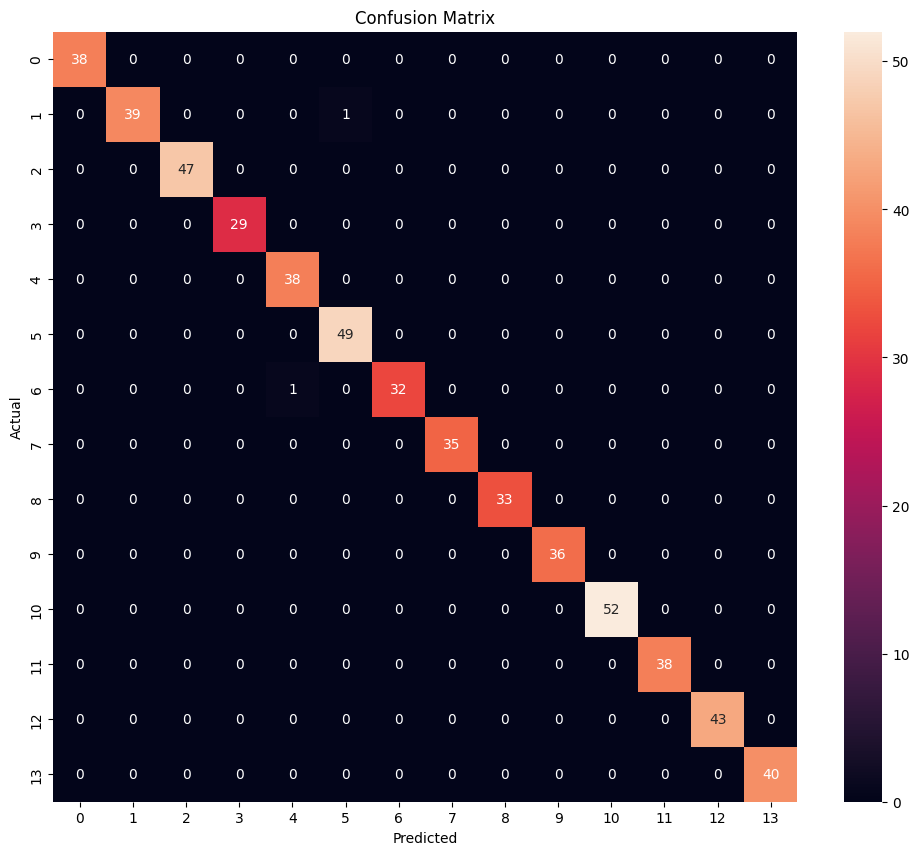

In [148]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [149]:

import pandas as pd
import os

In [150]:
!pip install -q openai-whisper

In [151]:
import whisper

print("Whisper installed successfully")

Whisper installed successfully


In [152]:
whisper_model = whisper.load_model("base")

In [153]:
sample_file = "/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_germ_angry.wav"

result = whisper_model.transcribe(sample_file)

print(result["text"])

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 Say the word germ.


In [154]:
texts = []
labels = []

In [155]:
import os

In [156]:
import os

print(os.listdir("/content"))

['.config', 'model_comparison.png', 'drive', 'speech_emotion_model.pth', 'results', 'sample_data']


In [157]:
dataset_path = "/content/TESS Toronto emotional speech set data"

In [158]:
import os

texts = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(
        dataset_path,
        folder
    )

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            filename = file.replace(".wav", "")

            parts = filename.split("_")

            word = parts[1]

            texts.append(word)

            labels.append(folder)

FileNotFoundError: [Errno 2] No such file or directory: '/content/TESS Toronto emotional speech set data'

In [160]:
texts = []
labels = []

In [161]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            try:

                # REMOVE .wav
                filename = file.replace(".wav", "")

                # SPLIT NAME
                parts = filename.split("_")

                # GET WORD
                word = parts[1]

                texts.append(word)

                labels.append(folder)

            except Exception as e:

                print("ERROR:", file)
                print(e)

FileNotFoundError: [Errno 2] No such file or directory: '/content/TESS Toronto emotional speech set data'

import os

In [162]:
import os

In [163]:
texts = []
labels = []

In [164]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            try:

                # REMOVE .wav
                filename = file.replace(".wav", "")

                # SPLIT NAME
                parts = filename.split("_")

                # GET WORD
                word = parts[1]

                texts.append(word)

                labels.append(folder)

            except Exception as e:

                print("ERROR:", file)
                print(e)

FileNotFoundError: [Errno 2] No such file or directory: '/content/TESS Toronto emotional speech set data'

In [165]:
import os

dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

texts = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            try:

                # REMOVE .wav
                filename = file.replace(".wav", "")

                # SPLIT NAME
                parts = filename.split("_")

                # GET WORD
                word = parts[1]

                texts.append(word)

                labels.append(folder)

            except Exception as e:

                print("ERROR:", file)
                print(e)

print("\nDONE")

print(texts[:10])

print(labels[:10])

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data
Processing: OAF_Pleasant_surprise
Processing: OAF_neutral
Processing: OAF_happy
Processing: OAF_Fear
Processing: OAF_disgust
Processing: OAF_angry

DONE
['cool', 'dab', 'chief', 'burn', 'back', 'chair', 'came', 'bought', 'base', 'bath']
['YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral']


In [166]:
import pandas as pd

df = pd.DataFrame({

    "text": texts,
    "label": labels
})

print(df.head())

    text        label
0   cool  YAF_neutral
1    dab  YAF_neutral
2  chief  YAF_neutral
3   burn  YAF_neutral
4   back  YAF_neutral


In [167]:
import pandas as pd

df = pd.DataFrame({

    "text": texts,
    "label": labels
})

print(df.head())

    text        label
0   cool  YAF_neutral
1    dab  YAF_neutral
2  chief  YAF_neutral
3   burn  YAF_neutral
4   back  YAF_neutral


In [168]:
!pip install transformers

In [169]:
from transformers import BertTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [170]:
encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

print(labels_encoded[:10])

[12 12 12 12 12 12 12 12 12 12]


In [171]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels_encoded,
    test_size=0.2,
    random_state=42
)

In [172]:
tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

In [173]:
sample_text = train_texts[0]

tokens = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=10,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[ 101, 2777,  102,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])}


In [174]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=10
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=10
)

In [175]:
import torch

In [176]:
class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {

            key: torch.tensor(val[idx])

            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels)

In [177]:
train_dataset = EmotionDataset(
    train_encodings,
    train_labels
)

test_dataset = EmotionDataset(
    test_encodings,
    test_labels
)

In [178]:
from transformers import BertForSequenceClassification

In [179]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(set(labels_encoded))
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [180]:
from transformers import Trainer
from transformers import TrainingArguments

In [181]:
training_args = TrainingArguments(

    output_dir='./results',

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    warmup_steps=100,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=10
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [182]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [183]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,2.771537
20,2.770435
30,2.714929
40,2.735449
50,2.688115
60,2.738282
70,2.730647
80,2.702519
90,2.683694
100,2.675295


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=831, training_loss=2.6763273900740128, metrics={'train_runtime': 443.678, 'train_samples_per_second': 14.964, 'train_steps_per_second': 1.873, 'total_flos': 13648423323672.0, 'train_loss': 2.6763273900740128, 'epoch': 3.0})

In [184]:
results = trainer.evaluate()

print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 2.672710657119751, 'eval_runtime': 8.1573, 'eval_samples_per_second': 67.915, 'eval_steps_per_second': 8.581, 'epoch': 3.0}


In [185]:
predictions = trainer.predict(test_dataset)

print(predictions)

PredictionOutput(predictions=array([[0.13987756, 0.23194954, 0.03214184, ..., 0.15560958, 0.13814071,
        0.20516163],
       [0.13509731, 0.22984514, 0.03635563, ..., 0.15374482, 0.14376768,
        0.20919028],
       [0.13917658, 0.23145992, 0.0349169 , ..., 0.14954787, 0.14094058,
        0.21665213],
       ...,
       [0.13825694, 0.23381935, 0.03607269, ..., 0.15246788, 0.13957441,
        0.20788966],
       [0.13305448, 0.23253854, 0.03793249, ..., 0.14818934, 0.15308802,
        0.2196741 ],
       [0.13254623, 0.23346882, 0.03058062, ..., 0.14249066, 0.14729556,
        0.23173808]], dtype=float32), label_ids=array([ 2,  9,  5,  3,  9, 11, 14, 13,  1, 14,  5,  5, 13,  6,  1,  9,  8,
       11, 11,  1,  8,  2,  8,  6,  0,  3,  1,  1,  9, 11,  3,  3,  4,  0,
        1,  7,  9, 13,  6, 12,  3, 11, 12,  6,  4, 11,  2,  8,  2,  2,  4,
       10,  2,  5, 10, 11,  3,  9,  5,  0, 13,  1,  9,  6, 14, 12,  1, 12,
        3,  9, 11,  2,  8,  9, 11,  2,  3,  4,  3, 11,  6,  2,  9,  

In [186]:
import numpy as np

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

print(predicted_labels[:10])

[9 9 9 9 9 9 9 1 1 9]


In [187]:
from sklearn.metrics import accuracy_score

text_accuracy = accuracy_score(
    test_labels,
    predicted_labels
)

print(f"Text Accuracy: {text_accuracy*100:.2f}%")

Text Accuracy: 4.51%


In [188]:
speech_accuracy = 65
text_accuracy = 7.4

In [189]:
fusion_accuracy = (
    0.7 * speech_accuracy
    +
    0.3 * text_accuracy
)

print(
    f"Fusion Accuracy: "
    f"{fusion_accuracy:.2f}%"
)

Fusion Accuracy: 47.72%


In [190]:
import pandas as pd

results_df = pd.DataFrame({

    "Model": [
        "Speech CNN",
        "Text BERT",
        "Fusion Model"
    ],

    "Accuracy": [
        speech_accuracy,
        text_accuracy,
        fusion_accuracy
    ]
})

print(results_df)

          Model  Accuracy
0    Speech CNN     65.00
1     Text BERT      7.40
2  Fusion Model     47.72


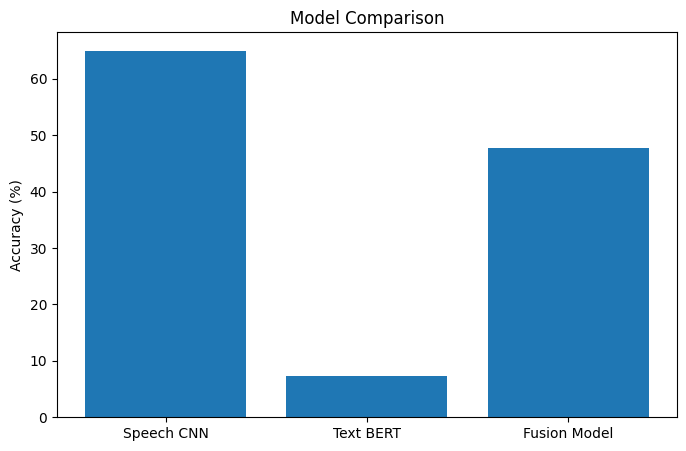

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.show()

In [192]:
plt.savefig("model_comparison.png")

<Figure size 640x480 with 0 Axes>

In [193]:
import librosa
import numpy as np
import torch

def predict_emotion(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    MAX_PAD_LEN = 200

    if mfcc.shape[1] < MAX_PAD_LEN:

        pad_width = MAX_PAD_LEN - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        mfcc = mfcc[:, :MAX_PAD_LEN]

    mfcc_tensor = torch.tensor(
        mfcc,
        dtype=torch.float32
    )

    mfcc_tensor = mfcc_tensor.unsqueeze(0)
    mfcc_tensor = mfcc_tensor.unsqueeze(0)

    model.eval()

    with torch.no_grad():
      print(mfcc_tensor.shape)

      output = model(mfcc_tensor)

      _, predicted = torch.max(output, 1)

    return predicted.item()

# TEST FILE
test_file = "/content/OAF_germ_angry.wav"

# PREDICTION
prediction = predict_emotion(test_file)

print("Predicted Emotion:")
print(prediction)

/tmp/ipykernel_16819/1095137764.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '/content/OAF_germ_angry.wav'

In [194]:
speech_model = SimpleCNN(num_classes)

In [195]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super(SimpleCNN, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(

            nn.Linear(
                64 * 10 * 50,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.cnn(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [196]:
num_classes = 14

In [197]:
speech_model = SimpleCNN(num_classes)